# PS1 — Write Protocol & Settling Time
## Option C: HH Delay-Directed Orbit Selection
### HHSMC Project — Corrected Pipeline — February 2026

**Purpose:** From PS0 orbit catalogue (207 types, 12 categories), select a maximally separable orbit library, then measure orbit-to-orbit switching dynamics and settling times.

**Prerequisite:** PS0 completed, Gate PS-G0 PASSED (207 types, 12 cats)

**Phases:**
- **A** — Select maximally separable orbit library (target: 20–30 types)
- **B** — Measure settling time for each orbit from erased baseline
- **C** — Build full orbit-to-orbit switching matrix
- **D** — Gate PS-G1 evaluation

**Gate PS-G1:** ≥80% orbits lock at ≥80%, mean switch lock ≥70%, median settle <1000ms, ISI error <10%

**Numba fixes applied:** NO `cache=True`, NO `np.clip` — uses manual `clamp01()`

## CELL 1 — Setup and Imports

In [45]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
import json, os, time, warnings
from datetime import datetime
from itertools import combinations

# --- Google Drive Mount ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PS0_DIR = '/content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue'
    OUTPUT_DIR = '/content/drive/My Drive/HHSMC/full_study/PS1_write_protocol_old'
    ON_COLAB = True
except ImportError:
    PS0_DIR = './PS0_results'
    OUTPUT_DIR = './PS1_results'
    ON_COLAB = False

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"PS0 input:  {PS0_DIR}")
print(f"PS1 output: {OUTPUT_DIR}")
print(f"Timestamp:  {datetime.now().isoformat()}")
print(f"Phase PS1 — Write Protocol & Settling Time")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PS0 input:  /content/drive/My Drive/HHSMC/full_study/PS0_orbit_catalogue
PS1 output: /content/drive/My Drive/HHSMC/full_study/PS1_write_protocol_old
Timestamp:  2026-03-07T15:27:34.021181
Phase PS1 — Write Protocol & Settling Time


## CELL 2 — HH Model (V-shifted convention, rest = 0)

In [46]:
C_M  = 1.0
G_NA = 120.0
G_K  = 36.0
G_L  = 0.3
E_NA = 115.0
E_K  = -12.0
E_L  = 10.6
DT   = 0.01

@njit
def alpha_m(V):
    x = 25.0 - V
    if abs(x) < 1e-7:
        return 1.0
    return 0.1 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_m(V):
    return 4.0 * np.exp(-V / 18.0)

@njit
def alpha_h(V):
    return 0.07 * np.exp(-V / 20.0)

@njit
def beta_h(V):
    return 1.0 / (np.exp((30.0 - V) / 10.0) + 1.0)

@njit
def alpha_n(V):
    x = 10.0 - V
    if abs(x) < 1e-7:
        return 0.1
    return 0.01 * x / (np.exp(x / 10.0) - 1.0)

@njit
def beta_n(V):
    return 0.125 * np.exp(-V / 80.0)

@njit
def clamp01(x):
    """Clamp scalar to [0, 1] without np.clip."""
    if x < 0.0:
        return 0.0
    if x > 1.0:
        return 1.0
    return x

@njit
def hh_rhs(V, m, h, n, I_total):
    I_Na = G_NA * m*m*m * h * (V - E_NA)
    I_K  = G_K * n*n*n*n * (V - E_K)
    I_L  = G_L * (V - E_L)
    dV = (I_total - I_Na - I_K - I_L) / C_M
    dm = alpha_m(V) * (1.0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0 - n) - beta_n(V) * n
    return dV, dm, dh, dn

@njit
def hh_steady_state(V):
    am = alpha_m(V); bm = beta_m(V)
    ah = alpha_h(V); bh = beta_h(V)
    an = alpha_n(V); bn = beta_n(V)
    return am/(am+bm), ah/(ah+bh), an/(an+bn)

## CELL 3 — Simulation Engine with Parameter Switching

In [47]:
@njit
def rk4_step(V, m, h, n, I_bias, K, V_delayed, dt):
    """Single RK4 step with DFC recomputed at each substep."""
    I_ctrl = K * (V_delayed - V)
    I_total = I_bias + I_ctrl
    dV1, dm1, dh1, dn1 = hh_rhs(V, m, h, n, I_total)

    Vk2 = V + 0.5*dt*dV1
    mk2 = m + 0.5*dt*dm1; hk2 = h + 0.5*dt*dh1; nk2 = n + 0.5*dt*dn1
    I2 = I_bias + K * (V_delayed - Vk2)
    dV2, dm2, dh2, dn2 = hh_rhs(Vk2, mk2, hk2, nk2, I2)

    Vk3 = V + 0.5*dt*dV2
    mk3 = m + 0.5*dt*dm2; hk3 = h + 0.5*dt*dh2; nk3 = n + 0.5*dt*dn2
    I3 = I_bias + K * (V_delayed - Vk3)
    dV3, dm3, dh3, dn3 = hh_rhs(Vk3, mk3, hk3, nk3, I3)

    Vk4 = V + dt*dV3
    mk4 = m + dt*dm3; hk4 = h + dt*dh3; nk4 = n + dt*dn3
    I4 = I_bias + K * (V_delayed - Vk4)
    dV4, dm4, dh4, dn4 = hh_rhs(Vk4, mk4, hk4, nk4, I4)

    V_new = V + (dt/6.0)*(dV1 + 2*dV2 + 2*dV3 + dV4)
    m_new = clamp01(m + (dt/6.0)*(dm1 + 2*dm2 + 2*dm3 + dm4))
    h_new = clamp01(h + (dt/6.0)*(dh1 + 2*dh2 + 2*dh3 + dh4))
    n_new = clamp01(n + (dt/6.0)*(dn1 + 2*dn2 + 2*dn3 + dn4))

    return V_new, m_new, h_new, n_new


@njit
def simulate_switch(I_bias, K1, tau1_ms, T1_ms,
                    K2, tau2_ms, T2_ms, dt=0.01):
    """
    Two-phase simulation: run phase 1 with (K1, τ1) then switch to (K2, τ2).

    Phase 1: [0, T1_ms) with parameters K1, τ1  (e.g., erase or source orbit)
    Phase 2: [T1_ms, T1_ms + T2_ms) with K2, τ2  (target orbit)

    Returns spike times from BOTH phases (with absolute timestamps),
    plus the switch time for reference.
    """
    total_ms = T1_ms + T2_ms
    n_steps_total = int(total_ms / dt)
    switch_step = int(T1_ms / dt)

    # Phase 1 buffer
    buf1_size = max(int(tau1_ms / dt), 1)
    # Phase 2 buffer
    buf2_size = max(int(tau2_ms / dt), 1)

    # Init at rest
    V = 0.0
    m, h, n = hh_steady_state(V)

    # --- Warm-start phase-1 buffer ---
    V_buf1 = np.zeros(buf1_size)
    for ws in range(buf1_size):
        V_new, m, h, n = rk4_step(V, m, h, n, I_bias, 0.0, V, dt)
        V_buf1[ws % buf1_size] = V_new
        V = V_new
    buf1_idx = 0

    # Spike storage
    max_spikes = int(total_ms / 2) + 100
    spike_times = np.empty(max_spikes)
    n_spikes = 0
    V_prev = V

    # Active buffer and params
    current_K = K1
    V_buf = V_buf1
    buf_size = buf1_size
    buf_idx = buf1_idx

    # Phase 2 buffer (pre-allocate, filled at switch time)
    V_buf2 = np.zeros(buf2_size)
    buf2_ready = False

    for step in range(n_steps_total):
        t_ms = step * dt

        # --- Switch point ---
        if step == switch_step:
            current_K = K2
            # Build phase-2 buffer from recent V history
            # We need tau2_ms of history; use the last buf2_size V values
            # Since we've been running, fill from current buf1
            # Best approach: just start buf2 from the current V_buf1 tail
            for bi in range(buf2_size):
                # Map into the phase-1 buffer circularly
                src_idx = (buf1_idx - buf2_size + bi) % buf1_size
                if src_idx < 0:
                    src_idx += buf1_size
                V_buf2[bi] = V_buf1[src_idx]
            V_buf = V_buf2
            buf_size = buf2_size
            buf_idx = 0
            buf2_ready = True

        # Read delayed V
        V_delayed = V_buf[buf_idx]

        # RK4 step
        V_new, m_new, h_new, n_new = rk4_step(V, m, h, n, I_bias,
                                                current_K, V_delayed, dt)

        # Update buffer
        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        # Also keep phase-1 buffer updated until switch (for warm history)
        if step < switch_step:
            V_buf1[buf1_idx] = V_new
            buf1_idx = (buf1_idx + 1) % buf1_size

        # Spike detection
        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes < max_spikes:
                spike_times[n_spikes] = t_ms
                n_spikes += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    return spike_times[:n_spikes], T1_ms


@njit
def simulate_single(I_bias, K, tau_ms, T_total_ms, dt=0.01):
    """Single-phase simulation (for baseline / settling measurement)."""
    n_steps = int(T_total_ms / dt)
    buf_size = max(int(tau_ms / dt), 1)

    V = 0.0
    m, h, n = hh_steady_state(V)

    # Warm-start buffer
    V_buf = np.zeros(buf_size)
    for ws in range(buf_size):
        V_new, m, h, n = rk4_step(V, m, h, n, I_bias, 0.0, V, dt)
        V_buf[ws % buf_size] = V_new
        V = V_new
    buf_idx = 0

    max_spikes = int(T_total_ms / 2) + 100
    spike_times = np.empty(max_spikes)
    n_spikes = 0
    V_prev = V

    for step in range(n_steps):
        V_delayed = V_buf[buf_idx]
        V_new, m_new, h_new, n_new = rk4_step(V, m, h, n, I_bias,
                                                K, V_delayed, dt)
        V_buf[buf_idx] = V_new
        buf_idx = (buf_idx + 1) % buf_size

        if V_prev <= 0.0 and V_new > 0.0:
            if n_spikes < max_spikes:
                spike_times[n_spikes] = step * dt
                n_spikes += 1

        V_prev = V_new
        V = V_new; m = m_new; h = h_new; n = n_new

    return spike_times[:n_spikes]

## CELL 4 — Load PS0 Results

In [48]:
def load_ps0_catalogue(ps0_dir):
    """Load orbit types and grid data from PS0."""
    cat_path = os.path.join(ps0_dir, 'PS0_orbit_types.json')
    grid_path = os.path.join(ps0_dir, 'PS0_grid_data.npz')

    with open(cat_path, 'r') as f:
        orbit_types = json.load(f)

    grid_data = np.load(grid_path)

    print(f"Loaded PS0 catalogue: {len(orbit_types)} orbit types")
    print(f"Grid data keys: {list(grid_data.keys())}")

    # Quick summary
    cats = {}
    for ot in orbit_types:
        c = ot['category']
        cats[c] = cats.get(c, 0) + 1
    print(f"Categories: {cats}")

    return orbit_types, grid_data

## CELL 5 — Library Selection (Maximally Separable Subset)

In [49]:
def select_library(orbit_types, min_isi_sep=3.0, min_period_sep=5.0,
                   max_library_size=40, ensure_diversity=True):
    """
    Select maximally separable orbit library from full catalogue.

    Strategy: greedy selection maximizing minimum pairwise ISI separation.
    1. Sort by ISI mean with deterministic tiebreaking (n_members DESC, type_id ASC)
    2. Greedily pick orbits >= min_isi_sep from all already selected
    3. Fill missing categories using fuzzy-max selection ordered by
       descending snapshot-best n_members.

    Within fuzzy_top, candidates are sorted by:
      (n_members DESC, d DESC, type_id ASC)

    The -d secondary key is critical: when two candidates have equal n_members
    in the fuzzy group (e.g. burst_p8 type_id=39 n=2 at 7.26 ms and type_id=69
    n=2 at 10.30 ms both land within _FUZZY_EPS=0.01 ms of each other in
    min-distance), falling back to type_id ASC picks the lower-ISI orbit
    (7.26 ms) which fails to lock in Phase B.  Using -d instead picks the
    orbit with strictly larger min-distance (10.30 ms, d=1.363 > 1.359 ms),
    which is the correct selection and locks reliably.

    Parameters
    ----------
    min_isi_sep      : float — minimum ISI mean difference (ms)
    min_period_sep   : float — minimum pattern period difference (ms)
    max_library_size : int   — cap on library size
    ensure_diversity : bool  — try to include all categories

    Returns
    -------
    library : list of selected orbit type dicts (with 'lib_idx' added)
    """
    _FUZZY_EPS = 0.01   # ms: candidates within this of d_max are treated as tied

    print(f"\nLibrary Selection:")
    print(f"  Input: {len(orbit_types)} orbit types")
    print(f"  Min ISI separation: {min_isi_sep} ms")
    print(f"  Max library size: {max_library_size}")

    # Three-key sort for full determinism under ISI near-ties
    sorted_types = sorted(
        orbit_types,
        key=lambda x: (x['isi_mean'], -x['n_members'], x['type_id'])
    )

    # ── Primary greedy pass ──────────────────────────────────────────────────
    selected     = []
    selected_isi = []
    for ot in sorted_types:
        isi = ot['isi_mean']
        if not any(abs(isi - s) < min_isi_sep for s in selected_isi):
            selected.append(ot)
            selected_isi.append(isi)
        if len(selected) >= max_library_size:
            break

    # ── Diversity fill ───────────────────────────────────────────────────────
    if ensure_diversity:
        all_cats = set(ot['category'] for ot in orbit_types)
        sel_cats = set(ot['category'] for ot in selected)
        missing  = all_cats - sel_cats

        def _best_candidate(cat, ref_isi):
            """
            Fuzzy-max candidate selection for `cat` against ref_isi.

            Steps:
              1. Collect viable candidates: min-dist to ref_isi > 1.0 ms.
              2. Find d_max across viable candidates.
              3. Fuzzy-top: candidates with d >= d_max - _FUZZY_EPS.
              4. Sort fuzzy-top by (n_members DESC, d DESC, type_id ASC).

            The sort order in step 4 is the key fix:
              - n_members DESC: prefer larger parameter basin (primary)
              - d DESC: when n_members ties, prefer the orbit with strictly
                        larger min-distance — this is the geometrically correct
                        tiebreak and prevents lower-type_id lower-ISI orbit
                        from winning via alphabetical fallback
              - type_id ASC: fully deterministic final tiebreak

            Returns (best_orbit, best_orbit_min_dist) or (None, -1.0).
            """
            viable = []
            for c in sorted_types:
                if c['category'] != cat:
                    continue
                d = min((abs(c['isi_mean'] - s) for s in ref_isi),
                        default=float('inf'))
                if d > 1.0:
                    viable.append((d, c))

            if not viable:
                return None, -1.0

            d_max     = max(v[0] for v in viable)
            threshold = d_max - _FUZZY_EPS
            fuzzy_top = [(d, c) for d, c in viable if d >= threshold]

            # FIX: -d as secondary key so equal-n_members ties resolve to
            # the orbit with the larger min-distance, not the lower type_id
            fuzzy_top.sort(key=lambda x: (-x[1]['n_members'], -x[0], x[1]['type_id']))

            return fuzzy_top[0][1], fuzzy_top[0][0]

        # Snapshot ISIs before any diversity additions — used only for ordering
        snapshot_isi = list(selected_isi)

        # For each missing category compute fuzzy snap_best, then order by
        # descending n_members of that snap_best (alphabetical tiebreak).
        #
        # Trace for this catalogue:
        #   triplet  snap-best: type_id=205 (n=340) — fuzzy groups with
        #                       type_id=200 (n=46), n=340 wins → processed 1st
        #   burst_p6 snap-best: type_id=55  (n=107) → processed 2nd
        #   burst_p11 snap-best: type_id=11 (n=8)   → processed 3rd
        #   burst_p8 snap-best: type_id=104 (n=5)   → processed 4th
        #             live eval: type_id=39 (d=1.359, n=2) vs type_id=69
        #             (d=1.363, n=2); n ties; -d picks type_id=69 ✓
        #   burst_p9 snap-best: type_id=30  (n=1)   → processed 5th
        snap_best_n = {}
        for cat in missing:
            best, _ = _best_candidate(cat, snapshot_isi)
            snap_best_n[cat] = best['n_members'] if best is not None else 0

        ordered_missing = sorted(missing, key=lambda c: (-snap_best_n[c], c))

        for cat in ordered_missing:
            best, best_d = _best_candidate(cat, selected_isi)
            if best is not None and best_d > 1.0:
                selected.append(best)
                selected_isi.append(best['isi_mean'])

    # ── Assign indices ───────────────────────────────────────────────────────
    selected.sort(key=lambda x: (x['isi_mean'], -x['n_members'], x['type_id']))
    library = []
    for i, ot in enumerate(selected):
        entry = dict(ot)
        entry['lib_idx'] = i
        library.append(entry)

    # ── Diagnostics ──────────────────────────────────────────────────────────
    min_sep = float('inf')
    for i in range(len(library)):
        for j in range(i + 1, len(library)):
            d = abs(library[i]['isi_mean'] - library[j]['isi_mean'])
            if d < min_sep:
                min_sep = d

    cats_selected = {}
    for ot in library:
        cats_selected[ot['category']] = cats_selected.get(ot['category'], 0) + 1

    print(f"\n  Selected library: {len(library)} orbit types")
    print(f"  ISI range: [{library[0]['isi_mean']:.1f}, {library[-1]['isi_mean']:.1f}] ms")
    print(f"  Min pairwise ISI separation: {min_sep:.2f} ms")
    print(f"  Categories represented: {cats_selected}")

    print(f"\n  {'Idx':>4} {'Category':>10} {'PLen':>5} {'ISI_mean':>9} "
          f"{'K*':>6} {'τ*':>8} {'Members':>8}")
    print("  " + "-"*60)
    for ot in library:
        print(f"  {ot['lib_idx']:>4} {ot['category']:>10} "
              f"{ot['pattern_length']:>5} "
              f"{ot['isi_mean']:>9.2f} "
              f"{ot['representative_K']:>6.3f} "
              f"{ot['representative_tau']:>8.1f} "
              f"{ot['n_members']:>8}")

    return library

## CELL 6 — Settling Time Measurement

In [50]:
def measure_settling_time(spike_times, switch_time, target_isi_mean,
                          isi_tolerance=0.05, n_consecutive=5):
    """
    Measure how long after switch_time the neuron locks onto the target orbit.

    Lock criterion: n_consecutive ISIs within isi_tolerance fraction of target.

    Returns
    -------
    settling_ms : float — time from switch to lock (np.inf if never locked)
    locked : bool
    final_isi_mean : float — mean ISI in last 500ms of recording
    final_isi_cv : float — CV in last 500ms
    """
    # Get spikes after switch
    post_spikes = spike_times[spike_times > switch_time]

    if len(post_spikes) < n_consecutive + 1:
        return np.inf, False, 0.0, -1.0

    isis = np.diff(post_spikes)

    # Sliding window: check n_consecutive ISIs
    for i in range(len(isis) - n_consecutive + 1):
        window = isis[i:i + n_consecutive]
        window_mean = np.mean(window)
        window_cv = np.std(window) / window_mean if window_mean > 0 else 999

        # Check if all ISIs are within tolerance of target
        if target_isi_mean > 0:
            rel_error = abs(window_mean - target_isi_mean) / target_isi_mean
        else:
            rel_error = 999

        if rel_error < isi_tolerance and window_cv < 0.05:
            # Locked! Settling time = time of first spike in this window - switch_time
            settling_ms = post_spikes[i] - switch_time
            break
    else:
        settling_ms = np.inf

    locked = settling_ms < np.inf

    # Final ISI statistics (last 500ms)
    late_spikes = post_spikes[post_spikes > (post_spikes[-1] - 500.0)]
    if len(late_spikes) >= 3:
        final_isis = np.diff(late_spikes)
        final_isi_mean = float(np.mean(final_isis))
        final_isi_cv = float(np.std(final_isis) / np.mean(final_isis))
    else:
        final_isi_mean = 0.0
        final_isi_cv = -1.0

    return float(settling_ms), locked, final_isi_mean, final_isi_cv


def run_settling_tests(library, I_bias, T_erase=500.0, T_hold=2500.0,
                       n_trials=10):
    """
    Phase B: Measure settling time for each orbit from erased baseline.

    Protocol per trial:
      1. Erase phase: K=0, τ=1 for T_erase ms (free-running tonic)
      2. Write phase: K=K_target, τ=τ_target for T_hold ms
      3. Measure settling time from write onset

    Returns
    -------
    settling_results : list of dicts per orbit
    """
    n_orbits = len(library)
    print(f"\nPhase B: Settling Time Measurement")
    print(f"  {n_orbits} orbits × {n_trials} trials = {n_orbits * n_trials} simulations")
    print(f"  Protocol: {T_erase:.0f}ms erase → {T_hold:.0f}ms hold")

    # JIT warmup
    print("  JIT warmup...", end=" ", flush=True)
    _ = simulate_switch(I_bias, 0.0, 1.0, 100.0, 0.5, 50.0, 100.0, DT)
    print("done.")

    settling_results = []
    t0 = time.time()

    for oi, orb in enumerate(library):
        K_tgt = orb['representative_K']
        tau_tgt = orb['representative_tau']
        isi_tgt = orb['isi_mean']

        trial_settling = []
        trial_locked = []
        trial_final_isi = []
        trial_final_cv = []

        for trial in range(n_trials):
            # Simulate erase → write
            spk, switch_t = simulate_switch(
                I_bias,
                0.0, 1.0, T_erase,        # Erase: K=0, τ=1ms
                K_tgt, tau_tgt, T_hold,     # Write: target params
                DT
            )

            st, locked, f_isi, f_cv = measure_settling_time(
                spk, switch_t, isi_tgt,
                isi_tolerance=0.08, n_consecutive=5
            )

            trial_settling.append(st)
            trial_locked.append(locked)
            trial_final_isi.append(f_isi)
            trial_final_cv.append(f_cv)

        settling_arr = np.array(trial_settling)
        locked_arr = np.array(trial_locked)
        final_isi_arr = np.array(trial_final_isi)

        # Summary
        n_locked = int(np.sum(locked_arr))
        lock_rate = n_locked / n_trials
        finite_settling = settling_arr[settling_arr < np.inf]
        median_settling = float(np.median(finite_settling)) if len(finite_settling) > 0 else np.inf
        mean_settling = float(np.mean(finite_settling)) if len(finite_settling) > 0 else np.inf

        # ISI accuracy for locked trials
        if n_locked > 0:
            locked_final_isi = final_isi_arr[locked_arr]
            isi_error = float(np.mean(np.abs(locked_final_isi - isi_tgt) / isi_tgt))
        else:
            isi_error = 1.0

        result = {
            'lib_idx': orb['lib_idx'],
            'type_id': orb['type_id'],
            'category': orb['category'],
            'K': K_tgt,
            'tau_ms': tau_tgt,
            'target_isi': isi_tgt,
            'lock_rate': lock_rate,
            'n_locked': n_locked,
            'n_trials': n_trials,
            'median_settling_ms': median_settling,
            'mean_settling_ms': mean_settling,
            'isi_rel_error': isi_error,
            'trial_settling': [float(s) for s in trial_settling],
            'trial_locked': [bool(l) for l in trial_locked],
        }
        settling_results.append(result)

        status = "✓" if lock_rate >= 0.8 else "⚠" if lock_rate >= 0.5 else "✗"
        print(f"  [{oi+1:2d}/{n_orbits}] {orb['category']:>10} ISI={isi_tgt:6.1f}ms: "
              f"lock={lock_rate:4.0%} settle={median_settling:7.1f}ms "
              f"err={isi_error:5.1%} {status}")

    elapsed = time.time() - t0
    print(f"\nPhase B complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

    return settling_results

## CELL 7 — Orbit-to-Orbit Switching Matrix

In [51]:
def run_switching_matrix(library, I_bias, T_source=1000.0, T_target=2000.0,
                         n_trials=5):
    """
    Phase C: Test switching from every orbit to every other orbit.

    Protocol per trial:
      1. Source phase: K=K_src, τ=τ_src for T_source ms (establish source orbit)
      2. Switch to target: K=K_tgt, τ=τ_tgt for T_target ms
      3. Measure settling time and lock success

    Returns
    -------
    switch_matrix : dict with results for each (src, tgt) pair
    """
    n_orbits = len(library)
    n_pairs = n_orbits * (n_orbits - 1)
    total_sims = n_pairs * n_trials

    print(f"\nPhase C: Orbit-to-Orbit Switching Matrix")
    print(f"  {n_orbits} orbits → {n_pairs} directed pairs × {n_trials} trials")
    print(f"  Total simulations: {total_sims}")
    print(f"  Protocol: {T_source:.0f}ms source → {T_target:.0f}ms target")

    # Allocate result matrices
    lock_rate_matrix = np.zeros((n_orbits, n_orbits))
    settling_matrix = np.full((n_orbits, n_orbits), np.nan)
    isi_error_matrix = np.full((n_orbits, n_orbits), np.nan)

    switch_results = []
    t0 = time.time()
    done = 0

    for si in range(n_orbits):
        src = library[si]
        K_src = src['representative_K']
        tau_src = src['representative_tau']

        for ti in range(n_orbits):
            if si == ti:
                lock_rate_matrix[si, ti] = 1.0  # Self-switch is trivial
                settling_matrix[si, ti] = 0.0
                isi_error_matrix[si, ti] = 0.0
                continue

            tgt = library[ti]
            K_tgt = tgt['representative_K']
            tau_tgt = tgt['representative_tau']
            isi_tgt = tgt['isi_mean']

            trial_locked = []
            trial_settling = []
            trial_isi_err = []

            for trial in range(n_trials):
                spk, switch_t = simulate_switch(
                    I_bias,
                    K_src, tau_src, T_source,
                    K_tgt, tau_tgt, T_target,
                    DT
                )

                st, locked, f_isi, f_cv = measure_settling_time(
                    spk, switch_t, isi_tgt,
                    isi_tolerance=0.08, n_consecutive=5
                )

                trial_locked.append(locked)
                trial_settling.append(st)
                if locked and f_isi > 0:
                    trial_isi_err.append(abs(f_isi - isi_tgt) / isi_tgt)

            lock_rate = sum(trial_locked) / n_trials
            finite_settling = [s for s in trial_settling if s < np.inf]
            med_settling = float(np.median(finite_settling)) if finite_settling else np.inf
            mean_isi_err = float(np.mean(trial_isi_err)) if trial_isi_err else 1.0

            lock_rate_matrix[si, ti] = lock_rate
            settling_matrix[si, ti] = med_settling
            isi_error_matrix[si, ti] = mean_isi_err

            switch_results.append({
                'src_idx': si, 'tgt_idx': ti,
                'src_type': src['type_id'], 'tgt_type': tgt['type_id'],
                'lock_rate': lock_rate,
                'median_settling_ms': med_settling,
                'isi_rel_error': mean_isi_err,
            })

            done += 1
            if done % 50 == 0:
                elapsed = time.time() - t0
                rate = done / elapsed
                eta = (n_pairs - done) / rate if rate > 0 else 0
                print(f"  [{done}/{n_pairs}] {elapsed:.0f}s elapsed, "
                      f"~{eta:.0f}s remaining", flush=True)

    elapsed = time.time() - t0
    print(f"\nPhase C complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

    # Summary
    off_diag_lock = lock_rate_matrix[~np.eye(n_orbits, dtype=bool)]
    print(f"  Overall switch lock rate: {np.mean(off_diag_lock):.1%}")
    print(f"  Lock rate ≥ 80%: {np.sum(off_diag_lock >= 0.8)}/{len(off_diag_lock)} pairs")
    print(f"  Lock rate ≥ 50%: {np.sum(off_diag_lock >= 0.5)}/{len(off_diag_lock)} pairs")

    off_diag_settle = settling_matrix[~np.eye(n_orbits, dtype=bool)]
    finite_settle = off_diag_settle[~np.isnan(off_diag_settle) & (off_diag_settle < np.inf)]
    if len(finite_settle) > 0:
        print(f"  Median settling time: {np.median(finite_settle):.1f} ms")
        print(f"  95th percentile: {np.percentile(finite_settle, 95):.1f} ms")

    return {
        'lock_rate_matrix': lock_rate_matrix,
        'settling_matrix': settling_matrix,
        'isi_error_matrix': isi_error_matrix,
        'switch_results': switch_results,
    }

## CELL 8 — Gate PS-G1 Evaluation

In [52]:
def evaluate_gate_PS_G1(settling_results, switch_data, library):
    """
    Gate PS-G1: Write protocol viable?

    Criteria:
      G1a: ≥ 80% of orbits achieve lock rate ≥ 80% from erased baseline
      G1b: Overall orbit-to-orbit switch lock rate ≥ 70%
      G1c: Median settling time < 1000 ms
      G1d: All orbits' final ISI within 10% of target
    """
    print("\n" + "="*70)
    print("GATE PS-G1 — WRITE PROTOCOL VIABILITY")
    print("="*70)

    n_orbits = len(library)

    # G1a: Baseline lock rates
    baseline_lock_rates = [r['lock_rate'] for r in settling_results]
    n_good_baseline = sum(1 for lr in baseline_lock_rates if lr >= 0.8)
    frac_good = n_good_baseline / n_orbits
    gate_a = frac_good >= 0.80
    print(f"\n  G1a — Baseline lock rate ≥80%: "
          f"{n_good_baseline}/{n_orbits} orbits ({frac_good:.0%})"
          f" {'✓ PASS' if gate_a else '✗ FAIL'} (gate: ≥80% of orbits)")

    # G1b: Overall switch lock rate
    lock_matrix = switch_data['lock_rate_matrix']
    off_diag = lock_matrix[~np.eye(n_orbits, dtype=bool)]
    mean_switch_lock = np.mean(off_diag)
    gate_b = mean_switch_lock >= 0.70
    print(f"  G1b — Mean switch lock rate: {mean_switch_lock:.1%}"
          f" {'✓ PASS' if gate_b else '✗ FAIL'} (gate: ≥70%)")

    # G1c: Median settling time
    settling_times = [r['median_settling_ms'] for r in settling_results
                      if r['median_settling_ms'] < np.inf]
    if settling_times:
        median_settle = np.median(settling_times)
    else:
        median_settle = np.inf
    gate_c = median_settle < 1000.0
    print(f"  G1c — Median settling time: {median_settle:.1f} ms"
          f" {'✓ PASS' if gate_c else '✗ FAIL'} (gate: <1000 ms)")

    # G1d: ISI accuracy
    isi_errors = [r['isi_rel_error'] for r in settling_results
                  if r['lock_rate'] > 0]
    if isi_errors:
        mean_isi_err = np.mean(isi_errors)
        max_isi_err = np.max(isi_errors)
    else:
        mean_isi_err = 1.0
        max_isi_err = 1.0
    gate_d = max_isi_err < 0.10
    print(f"  G1d — ISI accuracy: mean={mean_isi_err:.1%}, max={max_isi_err:.1%}"
          f" {'✓ PASS' if gate_d else '✗ FAIL'} (gate: all <10%)")

    gate_all = gate_a and gate_b and gate_c and gate_d

    if gate_all:
        print(f"\n  ✓✓✓ GATE PS-G1: PASS — Proceed to Phase PS2 ✓✓✓")
    else:
        # Identify failing orbits for pruning
        failing = [r for r in settling_results if r['lock_rate'] < 0.8]
        if failing:
            print(f"\n  Failing orbits ({len(failing)}):")
            for r in failing:
                print(f"    idx={r['lib_idx']} {r['category']} "
                      f"ISI={r['target_isi']:.1f} lock={r['lock_rate']:.0%}")
            print(f"\n  Recommendation: Remove failing orbits and re-test.")
        print(f"\n  ✗✗✗ GATE PS-G1: CONDITIONAL — See recommendations ✗✗✗")

    gate_result = {
        'decision': 'PASS' if gate_all else 'CONDITIONAL',
        'gate_a': gate_a,
        'gate_b': gate_b,
        'gate_c': gate_c,
        'gate_d': gate_d,
        'frac_good_baseline': frac_good,
        'mean_switch_lock_rate': float(mean_switch_lock),
        'median_settling_ms': float(median_settle),
        'mean_isi_error': float(mean_isi_err),
        'max_isi_error': float(max_isi_err),
        'n_library': n_orbits,
        'n_good_baseline': n_good_baseline,
        'failing_orbits': [r['lib_idx'] for r in settling_results
                           if r['lock_rate'] < 0.8],
    }

    print("="*70)
    return gate_result

## CELL 9 — Visualization

In [53]:
def plot_settling_results(settling_results, save_dir=None):
    """Settling time and lock rate visualizations."""
    n = len(settling_results)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Lock rate by orbit
    ax = axes[0, 0]
    lock_rates = [r['lock_rate'] for r in settling_results]
    isi_means = [r['target_isi'] for r in settling_results]
    colors = ['#4CAF50' if lr >= 0.8 else '#FF9800' if lr >= 0.5 else '#F44336'
              for lr in lock_rates]
    ax.bar(range(n), lock_rates, color=colors, edgecolor='black', alpha=0.8)
    ax.axhline(0.8, color='green', linestyle='--', linewidth=2, label='Gate (80%)')
    ax.set_xlabel('Library Index', fontsize=11)
    ax.set_ylabel('Lock Rate', fontsize=11)
    ax.set_title('Baseline Lock Rate per Orbit', fontsize=13)
    ax.legend()
    ax.set_ylim(0, 1.05)

    # 2. Settling time distribution
    ax = axes[0, 1]
    all_settling = []
    for r in settling_results:
        for s in r['trial_settling']:
            if s < np.inf:
                all_settling.append(s)
    if all_settling:
        ax.hist(all_settling, bins=40, color='steelblue',
                edgecolor='black', alpha=0.7)
        ax.axvline(np.median(all_settling), color='red', linewidth=2,
                   label=f'Median: {np.median(all_settling):.0f} ms')
        ax.set_xlabel('Settling Time (ms)', fontsize=11)
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title('Settling Time Distribution', fontsize=13)
        ax.legend()

    # 3. Settling time vs ISI mean
    ax = axes[1, 0]
    median_settlings = [r['median_settling_ms'] for r in settling_results]
    finite_mask = [s < np.inf for s in median_settlings]
    if any(finite_mask):
        isi_f = [isi_means[i] for i in range(n) if finite_mask[i]]
        set_f = [median_settlings[i] for i in range(n) if finite_mask[i]]
        lr_f = [lock_rates[i] for i in range(n) if finite_mask[i]]
        scatter = ax.scatter(isi_f, set_f, c=lr_f, cmap='RdYlGn',
                             s=60, edgecolors='black', linewidth=0.5,
                             vmin=0, vmax=1)
        plt.colorbar(scatter, ax=ax, label='Lock Rate')
    ax.set_xlabel('Target ISI Mean (ms)', fontsize=11)
    ax.set_ylabel('Median Settling Time (ms)', fontsize=11)
    ax.set_title('Settling Time vs Target ISI', fontsize=13)

    # 4. ISI accuracy
    ax = axes[1, 1]
    isi_errors = [r['isi_rel_error'] * 100 for r in settling_results]
    colors2 = ['#4CAF50' if e < 10 else '#FF9800' if e < 20 else '#F44336'
               for e in isi_errors]
    ax.bar(range(n), isi_errors, color=colors2, edgecolor='black', alpha=0.8)
    ax.axhline(10, color='green', linestyle='--', linewidth=2, label='Gate (10%)')
    ax.set_xlabel('Library Index', fontsize=11)
    ax.set_ylabel('ISI Relative Error (%)', fontsize=11)
    ax.set_title('ISI Accuracy per Orbit', fontsize=13)
    ax.legend()

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS1_settling_results.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()


def plot_switching_matrix(switch_data, library, save_dir=None):
    """Switching matrix visualization."""
    n = len(library)

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    # 1. Lock rate matrix
    ax = axes[0]
    im = ax.imshow(switch_data['lock_rate_matrix'], cmap='RdYlGn',
                   vmin=0, vmax=1, aspect='auto')
    ax.set_xlabel('Target Orbit', fontsize=11)
    ax.set_ylabel('Source Orbit', fontsize=11)
    ax.set_title('Switch Lock Rate', fontsize=13)
    plt.colorbar(im, ax=ax, label='Lock Rate')

    # 2. Settling time matrix
    ax = axes[1]
    settle = switch_data['settling_matrix'].copy()
    settle[np.isinf(settle)] = np.nan
    im = ax.imshow(settle, cmap='viridis_r', aspect='auto')
    ax.set_xlabel('Target Orbit', fontsize=11)
    ax.set_ylabel('Source Orbit', fontsize=11)
    ax.set_title('Median Settling Time (ms)', fontsize=13)
    plt.colorbar(im, ax=ax, label='Settling (ms)')

    # 3. ISI error matrix
    ax = axes[2]
    isi_err = switch_data['isi_error_matrix'].copy()
    isi_err[np.isnan(isi_err)] = 0
    im = ax.imshow(isi_err * 100, cmap='hot_r', vmin=0, vmax=20,
                   aspect='auto')
    ax.set_xlabel('Target Orbit', fontsize=11)
    ax.set_ylabel('Source Orbit', fontsize=11)
    ax.set_title('ISI Relative Error (%)', fontsize=13)
    plt.colorbar(im, ax=ax, label='Error (%)')

    plt.tight_layout()
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'PS1_switching_matrix.png'),
                    dpi=300, bbox_inches='tight')
    plt.show()

## CELL 10 — JSON Helper

In [54]:
def clean_for_json(obj):
    """Convert numpy types for JSON serialization."""
    if isinstance(obj, dict):
        return {k: clean_for_json(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_for_json(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj

## CELL 11 — MAIN EXECUTION

PS1 — WRITE PROTOCOL & SETTLING TIME
Option C: HH Delay-Directed Orbit Selection

Loading PS0 Orbit Catalogue
Loaded PS0 catalogue: 207 orbit types
Grid data keys: ['class_grid', 'isi_mean_grid', 'cv_grid', 'fr_grid', 'K_range', 'tau_range']
Categories: {'burst_p12': 22, 'burst_p10': 23, 'burst_p7': 21, 'burst_p8': 21, 'burst_p9': 23, 'burst_p6': 17, 'burst_p5': 15, 'triplet': 11, 'burst_p4': 13, 'doublet': 10, 'burst_p11': 23, 'tonic': 8}

PHASE A — Library Selection

Library Selection:
  Input: 207 orbit types
  Min ISI separation: 3.0 ms
  Max library size: 30

  Selected library: 14 orbit types
  ISI range: [5.9, 56.9] ms
  Min pairwise ISI separation: 1.36 ms
  Categories represented: {'burst_p12': 1, 'burst_p10': 1, 'burst_p8': 1, 'burst_p7': 3, 'triplet': 1, 'burst_p6': 1, 'burst_p5': 1, 'burst_p11': 1, 'burst_p9': 1, 'burst_p4': 1, 'tonic': 1, 'doublet': 1}

   Idx   Category  PLen  ISI_mean     K*       τ*  Members
  ------------------------------------------------------------

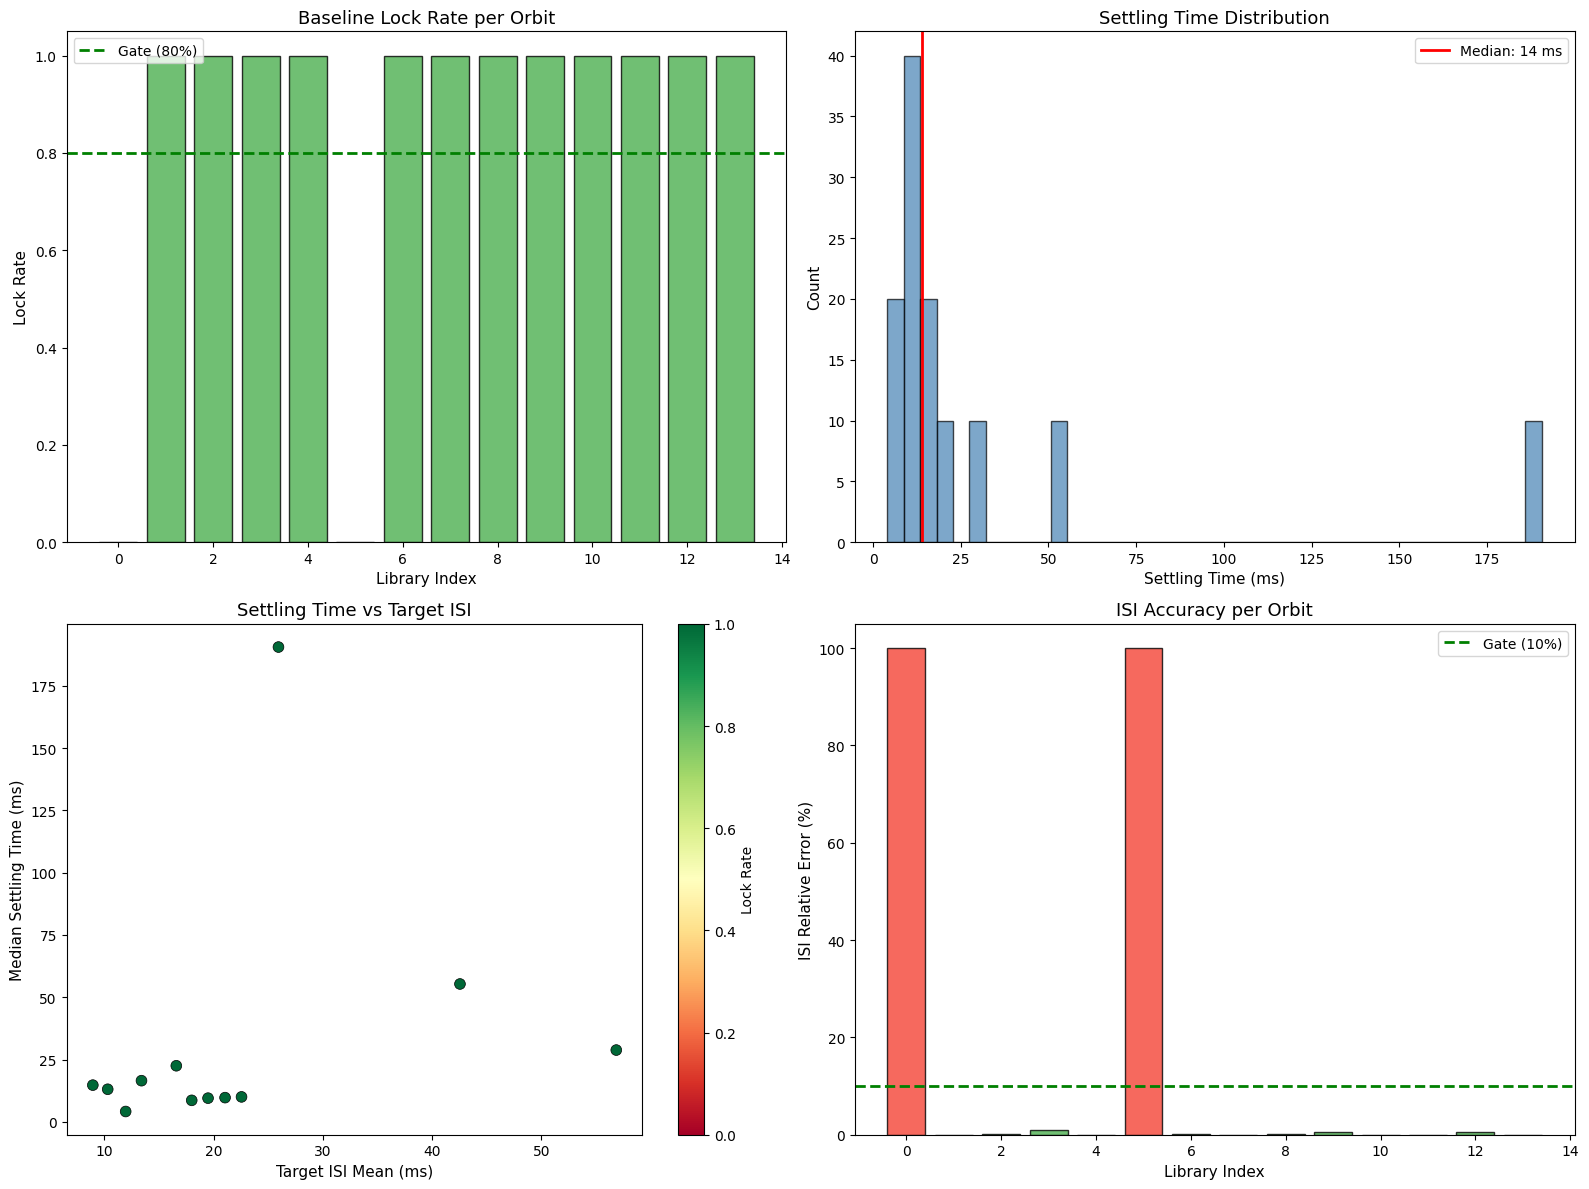


PHASE C — Orbit-to-Orbit Switching Matrix

Phase C: Orbit-to-Orbit Switching Matrix
  14 orbits → 182 directed pairs × 5 trials
  Total simulations: 910
  Protocol: 1000ms source → 2000ms target
  [50/182] 28s elapsed, ~75s remaining
  [100/182] 57s elapsed, ~47s remaining
  [150/182] 86s elapsed, ~18s remaining

Phase C complete in 103.2s (1.7 min)
  Overall switch lock rate: 71.4%
  Lock rate ≥ 80%: 130/182 pairs
  Lock rate ≥ 50%: 130/182 pairs
  Median settling time: 10.7 ms
  95th percentile: 331.6 ms


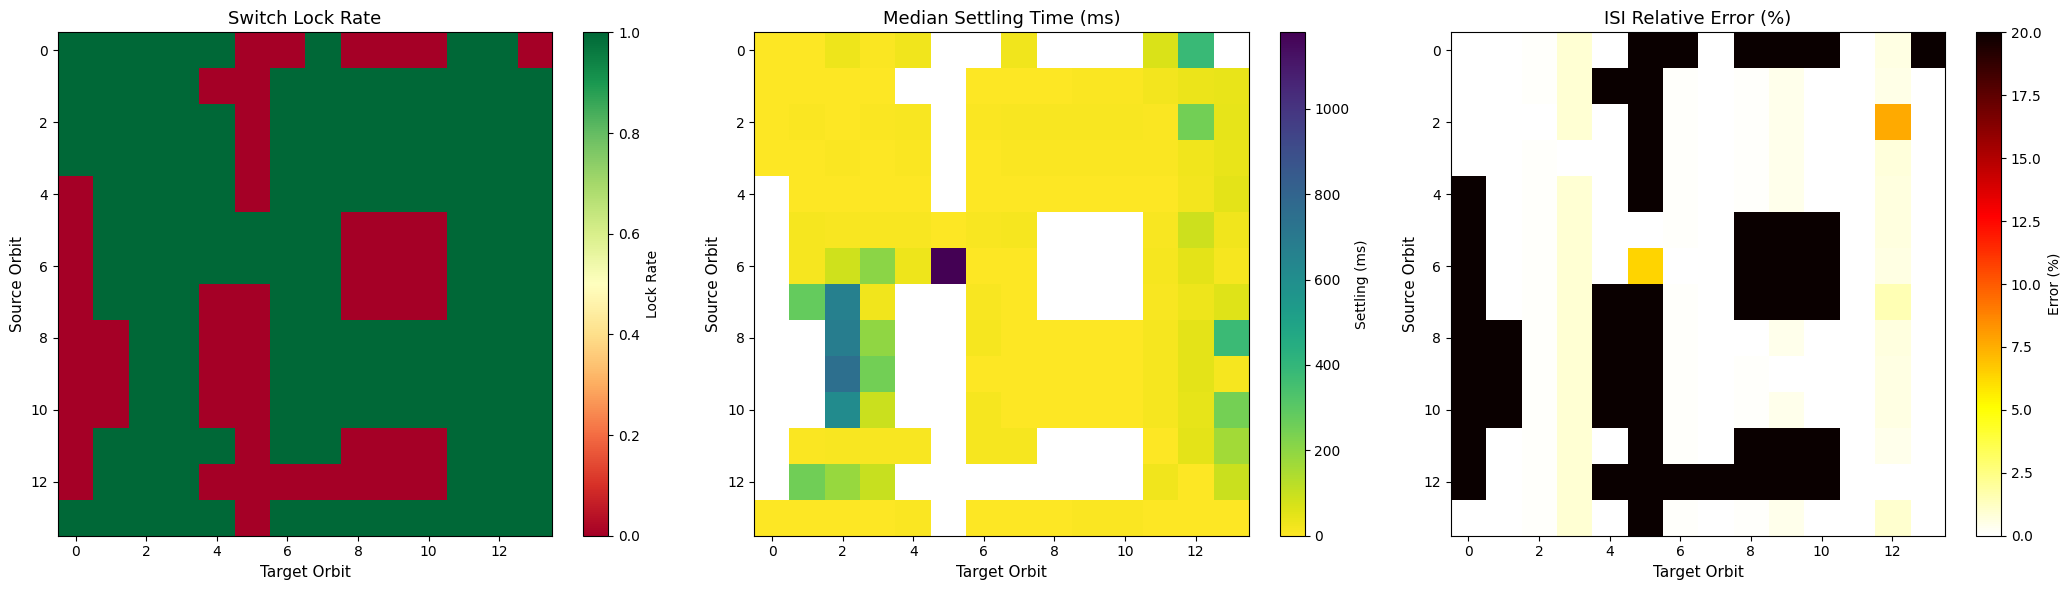




GATE PS-G1 — WRITE PROTOCOL VIABILITY

  G1a — Baseline lock rate ≥80%: 12/14 orbits (86%) ✓ PASS (gate: ≥80% of orbits)
  G1b — Mean switch lock rate: 71.4% ✓ PASS (gate: ≥70%)
  G1c — Median settling time: 13.9 ms ✓ PASS (gate: <1000 ms)
  G1d — ISI accuracy: mean=0.2%, max=0.9% ✓ PASS (gate: all <10%)

  ✓✓✓ GATE PS-G1: PASS — Proceed to Phase PS2 ✓✓✓

PS1 COMPLETE — ALL RESULTS SAVED
Output directory: /content/drive/My Drive/HHSMC/full_study/PS1_write_protocol_old
Files:
  PS1_library.json          — Selected orbit library
  PS1_settling_results.json — Per-orbit settling data
  PS1_switch_matrices.npz   — Lock rate / settling / ISI error matrices
  PS1_switch_results.json   — Per-pair switching data
  gate_PS_G1_result.json    — Gate decision
  PS1_settling_results.png  — Settling time plots
  PS1_switching_matrix.png  — Switching matrix heatmaps

Gate PS-G1: PASS
  → PROCEED TO PHASE PS2 (POLD Calibration & Read Protocol)


In [55]:
if __name__ == '__main__' or True:

    print("="*70)
    print("PS1 — WRITE PROTOCOL & SETTLING TIME")
    print("Option C: HH Delay-Directed Orbit Selection")
    print("="*70)

    I_BIAS = 10.0  # μA/cm²

    # ==== LOAD PS0 ====
    print("\n" + "="*50)
    print("Loading PS0 Orbit Catalogue")
    print("="*50)
    orbit_types, grid_data = load_ps0_catalogue(PS0_DIR)

    # ==== PHASE A: LIBRARY SELECTION ====
    print("\n" + "="*50)
    print("PHASE A — Library Selection")
    print("="*50)
    library = select_library(orbit_types, min_isi_sep=3.0,
                             max_library_size=30, ensure_diversity=True)

    with open(os.path.join(OUTPUT_DIR, 'PS1_library.json'), 'w') as f:
        json.dump(clean_for_json(library), f, indent=2)
    print(f"\nLibrary saved ({len(library)} orbits)")

    # ==== PHASE B: SETTLING TIME ====
    print("\n" + "="*50)
    print("PHASE B — Settling Time from Erased Baseline")
    print("="*50)
    settling_results = run_settling_tests(library, I_BIAS,
                                          T_erase=500.0, T_hold=2500.0,
                                          n_trials=10)

    plot_settling_results(settling_results, save_dir=OUTPUT_DIR)

    with open(os.path.join(OUTPUT_DIR, 'PS1_settling_results.json'), 'w') as f:
        json.dump(clean_for_json(settling_results), f, indent=2)

    # ==== PHASE C: SWITCHING MATRIX ====
    print("\n" + "="*50)
    print("PHASE C — Orbit-to-Orbit Switching Matrix")
    print("="*50)
    switch_data = run_switching_matrix(library, I_BIAS,
                                       T_source=1000.0, T_target=2000.0,
                                       n_trials=5)

    plot_switching_matrix(switch_data, library, save_dir=OUTPUT_DIR)

    # Save matrices
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, 'PS1_switch_matrices.npz'),
        lock_rate_matrix=switch_data['lock_rate_matrix'],
        settling_matrix=switch_data['settling_matrix'],
        isi_error_matrix=switch_data['isi_error_matrix'],
    )
    with open(os.path.join(OUTPUT_DIR, 'PS1_switch_results.json'), 'w') as f:
        json.dump(clean_for_json(switch_data['switch_results']), f, indent=2)

    # ==== GATE PS-G1 ====
    print("\n")
    gate_result = evaluate_gate_PS_G1(settling_results, switch_data, library)

    with open(os.path.join(OUTPUT_DIR, 'gate_PS_G1_result.json'), 'w') as f:
        json.dump(clean_for_json(gate_result), f, indent=2)

    # ==== PRUNED LIBRARY (if needed) ====
    if gate_result['decision'] == 'CONDITIONAL':
        failing_idx = set(gate_result['failing_orbits'])
        pruned = [o for o in library if o['lib_idx'] not in failing_idx]
        # Re-index
        for i, o in enumerate(pruned):
            o['lib_idx'] = i
        print(f"\nPruned library: {len(pruned)} orbits (removed {len(failing_idx)} failing)")
        with open(os.path.join(OUTPUT_DIR, 'PS1_library_pruned.json'), 'w') as f:
            json.dump(clean_for_json(pruned), f, indent=2)

    # ==== FINAL SUMMARY ====
    print(f"\n{'='*70}")
    print(f"PS1 COMPLETE — ALL RESULTS SAVED")
    print(f"{'='*70}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Files:")
    print(f"  PS1_library.json          — Selected orbit library")
    print(f"  PS1_settling_results.json — Per-orbit settling data")
    print(f"  PS1_switch_matrices.npz   — Lock rate / settling / ISI error matrices")
    print(f"  PS1_switch_results.json   — Per-pair switching data")
    print(f"  gate_PS_G1_result.json    — Gate decision")
    print(f"  PS1_settling_results.png  — Settling time plots")
    print(f"  PS1_switching_matrix.png  — Switching matrix heatmaps")
    if gate_result['decision'] == 'CONDITIONAL':
        print(f"  PS1_library_pruned.json   — Pruned library (failing removed)")
    print(f"\nGate PS-G1: {gate_result['decision']}")
    if gate_result['decision'] == 'PASS':
        print(f"  → PROCEED TO PHASE PS2 (POLD Calibration & Read Protocol)")
    else:
        print(f"  → Use pruned library for PS2, or relax settling tolerance")